In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sb
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.vis import plot_rdm
from SensoriMotorPrediction.force import calc_G_force
import PcmPy as pcm
import pingouin as pg

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


# Regressing out finger pre-activation from 1st-level GLM coefficients (Fig. R2)

## Setup

In [2]:
H = 'L'
rois = gl.rois['ROI']
glm = 12
mask = np.triu(np.ones((len(gl.cues), len(gl.cues))), k=1).astype(bool)
sep = [.5, 1.5, 2.5, 3.5, 4.5, 5.5]

# Behavioural pre-activation geometry (used to regress out of the BOLD RDMs)
behav = pd.read_csv(os.path.join('data', 'behavioural', 'behaviour.trial.tsv'), sep='\t')
N = behav.sn.nunique()
behav_block_cue = behav.groupby(['sn', 'BN', 'cue']).mean(numeric_only=True).reset_index()
G_force, _ = calc_G_force(behav_block_cue, prewhiten=False)
D_force = pcm.G_to_dist(G_force)

# Residual dissimilarities after regressing out the pre-activation geometry (cf. Fig. S4a)
D_res = np.zeros((len(rois), N, 5, 5))
for r, roi in enumerate(rois):
    G = np.load(os.path.join('data', 'representation', f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G).reshape(-1, 25)
    D_res_roi = np.zeros_like(D)
    for i in range(D.shape[0]):
        X = np.c_[np.ones(D.shape[1]), D_force.reshape(-1, 25)[i]]
        W = np.linalg.pinv(X) @ D[i]
        D_hat = X[:, 1] * W[1]
        D_res_roi[i] = D[i] - D_hat
    D_res[r] = D_res_roi.reshape(-1, 5, 5)

## Crossnobis dissimilarities after regressing out pre-activation

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=1.926, pval=0.038
PMd: tval=3.482, pval=0.002
PMv: tval=3.139, pval=0.004
M1: tval=3.492, pval=0.002
S1: tval=4.190, pval=0.001
SPLa: tval=3.407, pval=0.002
SPLp: tval=4.142, pval=0.001


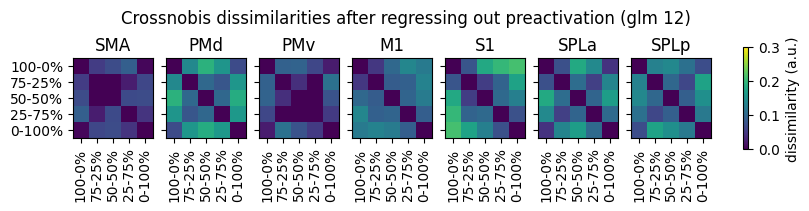

In [3]:
fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
vmin, vmax = 0, .3
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ols.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, gl.cues, vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities after regressing out preactivation (glm {glm})')
fig.savefig(os.path.join('figures', 'crossnobis.plan.preactivation_out.pdf'))
plt.show()

## Correlation of residual RDMs (RDM-based vs OLS-based regression)

In [4]:
for r, roi in enumerate(rois):
    # original
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D_ori = pcm.G_to_dist(G)[:, mask]
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ols.glm{glm}.{H}.{roi}.npy'))
    D_ols = pcm.G_to_dist(G)[:, mask]
    D_rdm = D_res[r][:, mask]

    corr_rdm = np.diag(np.corrcoef(np.r_[D_rdm, D_ori])[:N, N:])
    corr_ols = np.diag(np.corrcoef(np.r_[D_ols, D_ori])[:N, N:])

    ttest_one = ttest_1samp(corr_rdm, 0, alternative='greater')
    print(f'{roi}: rho (rdm)={corr_rdm.mean():.03f}, t-test against 0: t={ttest_one.statistic:.03f}, p={ttest_one.pvalue:.03f}')
    
    ttest_one = ttest_1samp(corr_ols, 0, alternative='greater')
    print(f'{roi}: rho (ols)={corr_ols.mean():.03f}, t-test against 0: t={ttest_one.statistic:.03f}, p={ttest_one.pvalue:.03f}')

SMA: rho (rdm)=0.947, t-test against 0: t=63.657, p=0.000
SMA: rho (ols)=0.821, t-test against 0: t=10.803, p=0.000
PMd: rho (rdm)=0.934, t-test against 0: t=52.616, p=0.000
PMd: rho (ols)=0.834, t-test against 0: t=14.994, p=0.000
PMv: rho (rdm)=0.911, t-test against 0: t=29.999, p=0.000
PMv: rho (ols)=0.872, t-test against 0: t=17.125, p=0.000
M1: rho (rdm)=0.860, t-test against 0: t=12.774, p=0.000
M1: rho (ols)=0.763, t-test against 0: t=6.009, p=0.000
S1: rho (rdm)=0.788, t-test against 0: t=12.191, p=0.000
S1: rho (ols)=0.761, t-test against 0: t=6.132, p=0.000
SPLa: rho (rdm)=0.953, t-test against 0: t=63.753, p=0.000
SPLa: rho (ols)=0.870, t-test against 0: t=19.505, p=0.000
SPLp: rho (rdm)=0.858, t-test against 0: t=18.223, p=0.000
SPLp: rho (ols)=0.810, t-test against 0: t=10.774, p=0.000


## Component model weights

                           T     p-val
roi  method                           
M1   ols    T-test  1.755221  0.051371
     raw    T-test  2.446785  0.014695
PMd  ols    T-test  2.017817  0.032369
     raw    T-test  3.697104  0.001342
PMv  ols    T-test  0.833742  0.209741
     raw    T-test  1.618486  0.064776
S1   ols    T-test  2.795206  0.007584
     raw    T-test  3.397400  0.002383
SMA  ols    T-test  0.773872  0.226425
     raw    T-test  1.081856  0.149488
SPLa ols    T-test  1.883373  0.041107
     raw    T-test  3.034924  0.004787
SPLp ols    T-test  2.135814  0.026146
     raw    T-test  3.251405  0.003156


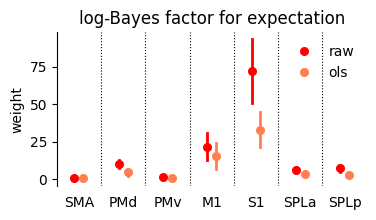

In [5]:
comp_model = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, 'component_model.BOLD.tsv'), sep='\t')
comp_model = comp_model[(comp_model.epoch=='plan') & (comp_model.glm==glm) & (comp_model.Hem==H)].reset_index()
comp_model['norm_weight'] = np.sqrt(comp_model['weight'] / comp_model['noise'])
comp_model_exp = comp_model[comp_model.component=='expectation']
comp_model_unc = comp_model[comp_model.component=='uncertainty']

fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_exp, x='roi', y='BF', hue='method', palette=['red', 'coral'], errorbar='se', linestyles='none', dodge=.2, lw=2)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
#ax.spines[['left']].set_bounds(0, 40)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for expectation')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
ttest = comp_model_exp.groupby(['roi', 'method']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
print(ttest[['T', 'p-val', ]])
plt.show()

                           T     p-val
roi  method                           
M1   ols    T-test  1.570054  0.070207
     raw    T-test  1.420972  0.089433
PMd  ols    T-test  2.249855  0.021209
     raw    T-test  2.108148  0.027496
PMv  ols    T-test  2.156136  0.025194
     raw    T-test  2.124096  0.026710
S1   ols    T-test  2.400820  0.016018
     raw    T-test  2.164677  0.024804
SMA  ols    T-test  1.600291  0.066772
     raw    T-test  1.570233  0.070186
SPLa ols    T-test  1.750278  0.051809
     raw    T-test  1.675392  0.058864
SPLp ols    T-test  3.118166  0.004078
     raw    T-test  2.985036  0.005269


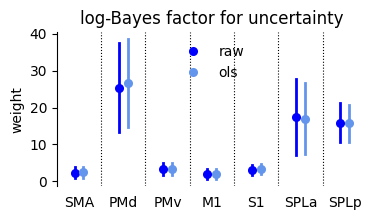

In [6]:
fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_unc, x='roi', y='BF', hue='method', palette=['blue', 'cornflowerblue'], errorbar='se', linestyles='none', lw=2, dodge=.2)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
#axs[0].spines[['left']].set_bounds(0, 30)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for uncertainty')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
ttest = comp_model_unc.groupby(['roi', 'method']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
print(ttest[['T', 'p-val']])
plt.show()

               T     p-unc
roi                       
M1   0 -1.638940  0.062594
PMd  0 -2.533299  0.012484
PMv  0 -2.383504  0.016545
S1   0 -1.861007  0.042753
SMA  0 -0.458903  0.326941
SPLa 0 -1.632065  0.063320
SPLp 0 -2.450897  0.014582


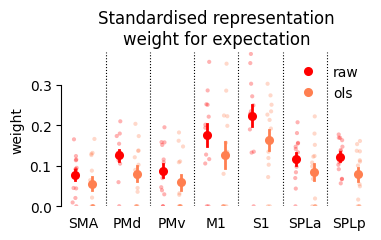

In [7]:
fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_exp, x='roi', y='norm_weight', hue='method', palette=['red', 'coral'], errorbar='se', linestyles='none', lw=2, dodge=.4)
sb.stripplot(ax=ax, data=comp_model_exp, x='roi', y='norm_weight', hue='method', size=3, palette=['red', 'coral'], jitter=.1, dodge=True, legend=False, alpha=.3)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(0, .3)
ax.set_ylim(0, .38)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation\nweight for expectation')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
ttest = comp_model_exp.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='method', subject='participant_id', alternative='less'))
print(ttest[['T', 'p-unc']])
fig.savefig(os.path.join('figures', 'weight.plan.preact_out.expectation.pdf'))
plt.show()